# DeepSeek-Foundations · Workbook 05

### Optimization — from gradient descent to Adam, and why training LLMs is hard

**Series:** DeepSeek-Foundations v1.0 · **Runtime:** ~75 min · **Prereqs:** Workbooks 02, 03 (lightly)

**Abstract.** Every parameter in a modern LLM is produced by a numerical optimizer chasing a single scalar: the training loss. This workbook develops that optimizer from first principles. We define the loss landscape and the stationarity condition any solution must satisfy, build gradient descent and show exactly how the learning rate decides between convergence, oscillation and divergence, then dissect why curvature makes naive descent crawl — the conditioning problem — and how momentum, stochastic gradients and per-parameter adaptive steps (Adam) each repair one piece of it. We close with the recipe that actually trains LLMs at scale — AdamW, warmup, cosine decay — and why high-dimensional landscapes make saddle points, not local minima, the real obstacle. Every section ships with a minimal NumPy experiment you can rerun and modify in place.

**How this fits the series:** this workbook continues the DeepSeek-Foundations curriculum — see [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb) for the full map, and [Workbook 06 — Neural Networks](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/06_Neural_Networks.ipynb) for where these optimizers meet a parameterized model.

## 1. The problem — loss landscapes and the goal of optimization

Training a model means choosing parameters $\theta \in \mathbb{R}^d$ that make a loss function $\mathcal{L}(\theta)$ as small as possible:

$$\theta^* = \arg\min_{\theta \in \mathbb{R}^d} \mathcal{L}(\theta)$$

For a language model, $\mathcal{L}$ is (a shard of) the cross-entropy over next-token predictions, $d$ is on the order of $10^9$–$10^{12}$, and $\mathcal{L}$ has no closed-form minimizer — we can only *walk* downhill. The walk is guided by the gradient $\nabla \mathcal{L}(\theta) \in \mathbb{R}^d$, the vector of partial derivatives. At any interior solution the gradient must vanish:

$$\nabla \mathcal{L}(\theta^*) = 0$$

A point with $\nabla \mathcal{L}(\theta) = 0$ is *stationary*; it can be a local minimum, a local maximum, or a saddle. Since we can only ever hope to reach stationary points, the entire game of optimization is: *move so that the loss decreases, until the gradient is numerically zero*. The experiment below makes the objects concrete in one dimension: a loss curve, its derivative, and the point where the derivative vanishes.

In [1]:
import numpy as np

# A small 1D loss function and its derivative
def loss(x):
    return 0.5 * x**2 + np.sin(x)

def grad(x):
    return x + np.cos(x)

xs = np.array([-2.0, -1.0, 0.0, 0.5, 1.0, 2.0])
print("   x      L(x)      L'(x)")
for x in xs:
    print(f"{x:6.2f}  {loss(x):8.4f}  {grad(x):8.4f}")

# Where does the derivative vanish?  (fine grid scan -> near-stationary point)
grid = np.linspace(-3.0, 3.0, 6001)
i = int(np.argmin(np.abs(grad(grid))))
print(f"\nnear-stationary point: x = {grid[i]:.4f}   (L = {loss(grid[i]):.4f})")
print(f"gradient there: {grad(grid[i]):+.2e}   -> stationary to numerical precision")
print("\nPattern to notice: where L'(x) < 0 the function is falling (step right),")
print("where L'(x) > 0 it is rising (step left). The derivative tells us which way to go.")

   x      L(x)      L'(x)
 -2.00    1.0907   -2.4161
 -1.00   -0.3415   -0.4597
  0.00    0.0000    1.0000
  0.50    0.6044    1.3776
  1.00    1.3415    1.5403
  2.00    2.9093    1.5839

near-stationary point: x = -0.7390   (L = -0.4005)
gradient there: +1.42e-04   -> stationary to numerical precision

Pattern to notice: where L'(x) < 0 the function is falling (step right),
where L'(x) > 0 it is rising (step left). The derivative tells us which way to go.


## 2. Gradient descent — follow the negative gradient

The gradient points uphill; to descend, step against it:

$$\theta_{t+1} = \theta_t - \eta \nabla \mathcal{L}(\theta_t)$$

The scalar $\eta > 0$ is the **learning rate**. Why does this decrease the loss? For a small step, a first-order Taylor expansion gives

$$\mathcal{L}(\theta - \eta g) \approx \mathcal{L}(\theta) - \eta \|g\|^2, \qquad g = \nabla \mathcal{L}(\theta)$$

so the loss drops by $\eta \|g\|^2$ — as long as the step is small enough that the linear approximation holds. The catch: "small enough" is set by the *curvature*, and getting it wrong is not a minor annoyance.

Work the toy case $f(x) = x^2$, $f'(x) = 2x$: the update is $x_{t+1} = (1 - 2\eta)\, x_t$, a pure geometric decay with multiplier $1 - 2\eta$. Convergence requires $|1 - 2\eta| < 1$, i.e. $\eta < 1$. The multiplier also fixes the *character* of the walk:

- $0 < \eta < 0.5$: steady, monotone decay;
- $0.5 < \eta < 1$: decay with a sign flip every step — an oscillatory crawl;
- $\eta = 1$: perpetual oscillation between $x$ and $-x$ (the knife edge);
- $\eta > 1$: divergence, since $|1 - 2\eta| > 1$.

The demo runs the same 30-step walk at four learning rates. Watch which one lands near $x = 0$ smoothly, which one crawls there by zig-zagging, and which two blow up.

30 steps of gradient descent on f(x) = x^2, from x0 = 1.0
  eta    x_30          |x_30|     verdict        sign flips
  0.10        0.0012  1.2379e-03  converged       0
  0.90        0.0012  1.2379e-03  converged      29
  1.80  2813198901284.7485  2.8132e+12  diverged       29
  2.10  1427247692705962.0000  1.4272e+15  diverged       29


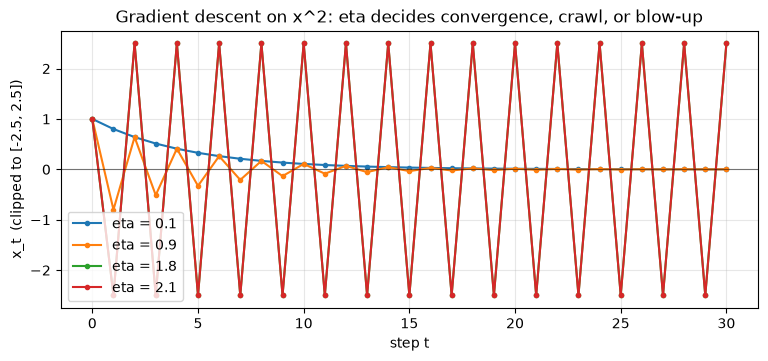

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# f(x) = x^2 with gradient 2x.  Closed form: x_t = (1 - 2*eta)^t * x_0.
def df(x):
    return 2.0 * x

x0 = 1.0
steps = 30
lrs = [0.1, 0.9, 1.8, 2.1]

print("30 steps of gradient descent on f(x) = x^2, from x0 = 1.0")
print("  eta    x_30          |x_30|     verdict        sign flips")
trajs = {}
for eta in lrs:
    x = x0
    traj = [x]
    flips = 0
    for k in range(steps):
        x_new = x - eta * df(x)
        if k > 0 and np.sign(x_new) != np.sign(traj[-1]):
            flips += 1
        traj.append(x_new)
        x = x_new
    trajs[eta] = traj
    ax = abs(x)
    if ax < 1e-2:
        verdict = "converged"
    elif ax > 1e3:
        verdict = "diverged"
    else:
        verdict = "still moving"
    print(f"  {eta:4.2f}  {x:12.4f}  {ax:10.4e}  {verdict:12s}  {flips:3d}")

# Trajectories, clipped so the two diverging runs stay on the plot
fig, ax = plt.subplots(figsize=(9, 3.6))
for eta in lrs:
    traj = np.clip(trajs[eta], -2.5, 2.5)
    ax.plot(range(steps + 1), traj, marker="o", ms=3, label=f"eta = {eta}")
ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
ax.set_xlabel("step t")
ax.set_ylabel("x_t  (clipped to [-2.5, 2.5])")
ax.set_title("Gradient descent on x^2: eta decides convergence, crawl, or blow-up")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 3. Curvature and conditioning — why descent zig-zags

The safe step size is set by curvature, measured by the Hessian $H(\theta) = \nabla^2 \mathcal{L}(\theta)$, the matrix of second derivatives. For the bowl

$$f(x, y) = x^2 + a\, y^2, \qquad H = \begin{pmatrix} 2 & 0 \\ 0 & 2a \end{pmatrix}, \qquad \lambda_{\max} = 2a$$

the eigenvalues of $H$ are exactly the curvatures along the coordinate axes. A quadratic analysis (Taylor-expand around the minimum, diagonalize $H$) shows that a gradient step multiplies the error along any eigen-direction by $1 - \eta \lambda$, so descent is stable only if

$$\eta < \frac{2}{\lambda_{\max}}$$

Exceeding this bound blows the walk up along the steepest direction; respecting it too timidly makes the shallow direction crawl. The ratio

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$$

is the **condition number**. For $a = 10$ we get $\kappa = 10$: the $y$-direction is ten times steeper than $x$. Gradient descent uses one isotropic step size for all directions, so the steep direction (which wants a *small* step) dictates $\eta$, and the shallow direction (which wants a *large* step) then moves ten times slower than it could — the path zig-zags as $y$ slams into the floor while $x$ barely inches forward. This mismatch, not gradient noise, is the first real enemy of training.

In [3]:
import numpy as np

# Bowl f(x, y) = x^2 + a*y^2 with a = 10  ->  H = diag(2, 20)
a = 10.0

def f(v):
    x, y = v
    return x * x + a * y * y

def grad(v):
    x, y = v
    return np.array([2.0 * x, 2.0 * a * y])

lams = np.array([2.0, 2.0 * a])                     # Hessian eigenvalues
print("Hessian eigenvalues:", lams)
print("lambda_max =", lams.max(),
      " -> safe learning rate bound: eta < 2/lambda_max =", 2.0 / lams.max())
print("condition number kappa = lambda_max / lambda_min =", lams.max() / lams.min())

eta = 0.08                                          # safe, but tuned for the steep direction
v = np.array([1.0, 1.0])
print(f"\nGradient descent from (1, 1), eta = {eta}:")
for k in range(8):
    print(f"  step {k}: x = {v[0]:8.4f}  y = {v[1]:8.4f}   f = {f(v):9.4f}")
    v = v - eta * grad(v)

for _ in range(52):                                 # finish 60 steps total
    v = v - eta * grad(v)
print(f"\nafter 60 steps: x = {v[0]:.3e}, y = {v[1]:.3e}   (f = {f(v):.3e})")
print("y hit the floor in ~10 steps while x took ~60: that is the zig-zag crawl.")

Hessian eigenvalues: [ 2. 20.]
lambda_max = 20.0  -> safe learning rate bound: eta < 2/lambda_max = 0.1
condition number kappa = lambda_max / lambda_min = 10.0

Gradient descent from (1, 1), eta = 0.08:
  step 0: x =   1.0000  y =   1.0000   f =   11.0000
  step 1: x =   0.8400  y =  -0.6000   f =    4.3056
  step 2: x =   0.7056  y =   0.3600   f =    1.7939
  step 3: x =   0.5927  y =  -0.2160   f =    0.8179
  step 4: x =   0.4979  y =   0.1296   f =    0.4158
  step 5: x =   0.4182  y =  -0.0778   f =    0.2354
  step 6: x =   0.3513  y =   0.0467   f =    0.1452
  step 7: x =   0.2951  y =  -0.0280   f =    0.0949

after 60 steps: x = 2.863e-05, y = 4.887e-14   (f = 8.194e-10)
y hit the floor in ~10 steps while x took ~60: that is the zig-zag crawl.


## 4. Momentum — give the walk inertia

The zig-zag wastes steps: the direction reverses every iteration in the steep direction while progress in the shallow direction is throttled. **Momentum** (heavy-ball) keeps a running velocity and adds the gradient into it, so persistent downhill motion accumulates and direction flips are averaged out:

$$v_{t+1} = \beta v_t + \nabla \mathcal{L}(\theta_t), \qquad \theta_{t+1} = \theta_t - \eta v_{t+1}, \qquad \beta \in [0, 1)$$

With $\beta = 0.9$, the velocity integrates roughly the last $1/(1-\beta) = 10$ gradients: components that keep pointing the same way (the shallow $x$-direction) get an effective learning-rate boost of up to $1/(1-\beta)$, while components that flip sign every step (the steep $y$-direction) partially cancel. Momentum also extends the stability window:

$$\eta < \frac{2(1+\beta)}{\lambda_{\max}} \quad \text{(momentum)} \qquad \text{vs} \qquad \eta < \frac{2}{\lambda_{\max}} \quad \text{(plain GD)}$$

One honest caveat: momentum's edge grows with the condition number. On the mild $\kappa = 10$ bowl of Section 3, heavy-ball at $\beta = 0.9$ actually *over-integrates* and trails plain GD; crank the bowl to $a = 100$ ($\kappa = 100$) and the picture inverts — GD crawls, momentum strides. The demo prints steps-to-convergence for both.

In [4]:
import numpy as np

# Same bowl family f(x, y) = x^2 + a*y^2, now with a = 100  (kappa = 100)
a = 100.0

def f(v):
    x, y = v
    return x * x + a * y * y

def grad(v):
    x, y = v
    return np.array([2.0 * x, 2.0 * a * y])

lams = np.array([2.0, 2.0 * a])
print("eigenvalues:", lams, " kappa =", lams.max() / lams.min())
print("plain GD stability:   eta < 2/lambda_max          =", 2.0 / lams.max())
print("momentum stability:   eta < 2(1+beta)/lambda_max  =", 2.0 * 1.9 / lams.max(), "(beta = 0.9)")

def run(eta, beta, tol=1e-6, max_steps=20000):
    v = np.array([1.0, 1.0])
    vel = np.zeros(2)
    for k in range(max_steps):
        g = grad(v)
        vel = beta * vel + g          # beta = 0 reduces to plain gradient descent
        v = v - eta * vel
        if f(v) < tol:
            return k + 1
    return max_steps

eta_gd, eta_mom = 0.009, 0.015         # each just inside its own stability bound
steps_gd = run(eta_gd, 0.0)
steps_mom = run(eta_mom, 0.9)
print(f"\nplain GD  (eta = {eta_gd}):        converged in {steps_gd} steps")
print(f"momentum (eta = {eta_mom}, beta = 0.9):  converged in {steps_mom} steps")
print(f"speedup: {steps_gd / steps_mom:.1f}x")

# Reference on the mild a = 10 bowl of Section 3 (reuses f/grad via global a)
a = 10.0
print("\nreference on the a = 10 bowl: plain GD", run(0.08, 0.0),
      "steps vs momentum", run(0.08, 0.9), "steps")
print("-> on kappa = 10, heavy-ball at beta = 0.9 over-integrates and loses;")
print("   on kappa = 100 it wins by ~2.8x. Conditioning decides.")

eigenvalues: [  2. 200.]  kappa = 100.0
plain GD stability:   eta < 2/lambda_max          = 0.01
momentum stability:   eta < 2(1+beta)/lambda_max  = 0.019 (beta = 0.9)

plain GD  (eta = 0.009):        converged in 381 steps
momentum (eta = 0.015, beta = 0.9):  converged in 138 steps
speedup: 2.8x

reference on the a = 10 bowl: plain GD 40 steps vs momentum 103 steps
-> on kappa = 10, heavy-ball at beta = 0.9 over-integrates and loses;
   on kappa = 100 it wins by ~2.8x. Conditioning decides.


## 5. Stochastic gradient descent — noise as a feature

The loss is an average over $N$ training examples, $\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^N \ell_i(\theta)$, so the full gradient costs $O(N)$ work per step — for an LLM's corpus, far more than fits in any machine. **Stochastic gradient descent** (SGD) instead draws a random **minibatch** $B$ of $m \ll N$ examples and uses

$$g_B(\theta) = \frac{1}{m} \sum_{i \in B} \nabla \ell_i(\theta), \qquad \theta_{t+1} = \theta_t - \eta\, g_B(\theta_t)$$

Because the batch is uniform, $\mathbb{E}_B[g_B] = \nabla \mathcal{L}(\theta)$ — the minibatch gradient is an *unbiased* estimator of the full gradient — and its variance scales like $1/m$. Two consequences:

- **Cost.** Each step touches $m$ examples instead of $N$; the per-step price drops by $N/m$, which is what makes training on billions of tokens possible at all.
- **Noise.** The estimator jitters around the true gradient. This is usually a *feature*: noise keeps the walk from stalling in sharp, narrow minima and acts as an implicit regularizer — at the price of a loss that never quite settles (it hovers around the noise floor unless the learning rate is decayed).

The demo fits a line $y = w x + b$ by least squares, pitting full-batch GD against SGD with batch size 8.

true parameters:          w = 1.5, b = -0.7
full-batch GD (eta=0.5):  w = 1.481, b = -0.724   final loss 0.0938   samples seen 30000
SGD batch=8 (eta=0.1):    w = 1.437, b = -0.713   final loss 0.0966   samples seen 1200

SGD's final loss is within 3.0% of full-batch GD's,
while seeing 25x fewer samples and paying 4% of the per-step cost.


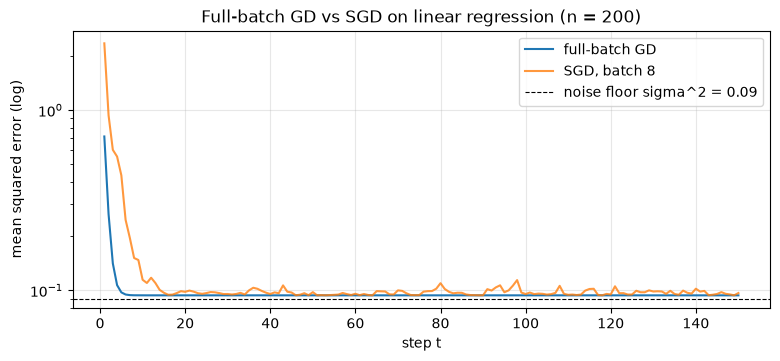

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 200
x = rng.uniform(-2.0, 2.0, size=n)
w_true, b_true = 1.5, -0.7
y = w_true * x + b_true + rng.normal(0.0, 0.3, size=n)   # sigma = 0.3 -> loss floor ~ 0.09

X = np.stack([x, np.ones_like(x)], axis=1)               # columns: [weight, bias]

def loss(theta):
    r = X @ theta - y
    return float(r @ r) / n

def full_grad(theta):
    r = X @ theta - y
    return 2.0 * X.T @ r / n

def batch_grad(theta, idx):
    r = X[idx] @ theta - y[idx]
    return 2.0 * X[idx].T @ r / len(idx)

steps, bs = 150, 8

# Full-batch gradient descent
theta_gd = np.zeros(2)
losses_gd = []
for _ in range(steps):
    theta_gd = theta_gd - 0.5 * full_grad(theta_gd)
    losses_gd.append(loss(theta_gd))

# SGD with minibatch of 8; smaller eta because the noise-limited floor scales with eta
theta_sgd = np.zeros(2)
losses_sgd = []
for _ in range(steps):
    idx = rng.integers(0, n, size=bs)
    theta_sgd = theta_sgd - 0.1 * batch_grad(theta_sgd, idx)
    losses_sgd.append(loss(theta_sgd))

print(f"true parameters:          w = {w_true}, b = {b_true}")
print(f"full-batch GD (eta=0.5):  w = {theta_gd[0]:.3f}, b = {theta_gd[1]:.3f}   "
      f"final loss {losses_gd[-1]:.4f}   samples seen {steps * n}")
print(f"SGD batch=8 (eta=0.1):    w = {theta_sgd[0]:.3f}, b = {theta_sgd[1]:.3f}   "
      f"final loss {losses_sgd[-1]:.4f}   samples seen {steps * bs}")
print(f"\nSGD's final loss is within {(losses_sgd[-1] / losses_gd[-1] - 1) * 100:.1f}% of "
      f"full-batch GD's,")
print(f"while seeing {steps * n / (steps * bs):.0f}x fewer samples and paying "
      f"{bs / n * 100:.0f}% of the per-step cost.")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.semilogy(range(1, steps + 1), losses_gd, label="full-batch GD")
ax.semilogy(range(1, steps + 1), losses_sgd, label="SGD, batch 8", alpha=0.8)
ax.axhline(0.3 ** 2, color="k", ls="--", lw=0.8, label="noise floor sigma^2 = 0.09")
ax.set_xlabel("step t")
ax.set_ylabel("mean squared error (log)")
ax.set_title("Full-batch GD vs SGD on linear regression (n = 200)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. Adam — one learning rate per parameter

GD and momentum still use a *single* step size for all $d$ parameters, so the conditioning problem persists in any direction that is not axis-aligned. **Adam** (Kingma & Ba, 2015) instead maintains per-parameter running estimates of the gradient mean $m_t$ (first moment) and of the squared gradient $v_t$ (second moment, uncentered variance):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$

Both are initialized at zero, which biases them toward zero early on; the **bias correction** divides by $1 - \beta^t$ to compensate:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}, \qquad \theta_{t+1} = \theta_t - \eta\, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

with defaults $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-8}$. The ratio $\hat{m}_t / \sqrt{\hat{v}_t}$ is a per-coordinate signal-to-noise ratio: coordinates whose gradients are consistently large (steep directions) get *small* normalized steps, coordinates whose gradients are consistently small (shallow directions) get *large* normalized steps. Every parameter effectively has its own learning rate — which is why Adam shrugs off conditioning that would cripple plain descent.

**AdamW** (Loshchilov & Hutter, 2019), the variant used for essentially all LLM training, makes one change: weight decay is applied *directly to the parameters*, $\theta \leftarrow \theta - \eta \lambda \theta$, instead of being folded into the gradient as L2 regularization. Inside Adam, L2 regularization interacts with the $v_t$ history and effectively decays weights *more* when their gradients are small; decoupling fixes this and improves generalization at scale.

The demo pits GD, momentum and Adam against the **Rosenbrock function**

$$f(x, y) = (1 - x)^2 + 100\,(y - x^2)^2$$

a valley that is flat along its floor and brutally steep across it (condition number $\approx 2500$ at the minimum). We start at the origin, on the valley floor: the gradient along $x$ is tiny, the gradient along $y$ is zero, and the minimum at $(1, 1)$ is far away. This is exactly the regime where per-parameter steps should win.

after 200 steps from (0, 0):
  GD       (eta=1e-3):         final loss 4.925e-01   point=(0.2989, 0.0863)
  Momentum (eta=1e-3, b=0.9):  final loss 2.668e-02   point=(0.8368, 0.6995)
  Adam     (eta=1e-1):         final loss 2.161e-04   point=(0.9856, 0.9718)

The valley floor is flat in y and nearly flat in x: gradient descent
takes steps proportional to a tiny gradient, so it crawls. Momentum
accumulates velocity and does better. Adam's per-coordinate
normalization promotes that tiny gradient to a full eta-sized step in
every coordinate - it wins by orders of magnitude.


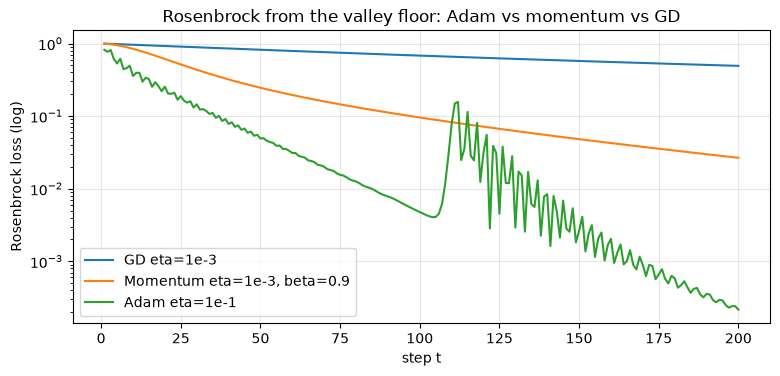

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Rosenbrock: f(x, y) = (1 - x)^2 + 100 (y - x^2)^2, minimum at (1, 1)
def f(v):
    x, y = v
    return (1.0 - x) ** 2 + 100.0 * (y - x * x) ** 2

def grad(v):
    x, y = v
    return np.array([-2.0 * (1.0 - x) - 400.0 * x * (y - x * x),
                     200.0 * (y - x * x)])

start = np.array([0.0, 0.0])     # on the valley floor, far from the minimum
steps = 200

def run_gd(eta, beta):
    v = start.copy()
    vel = np.zeros(2)
    hist = []
    for _ in range(steps):
        g = grad(v)
        vel = beta * vel + g
        v = v - eta * vel
        hist.append(f(v))
    return v, hist

def run_adam(eta, b1=0.9, b2=0.999, eps=1e-8):
    v = start.copy()
    m = np.zeros(2)
    s = np.zeros(2)
    hist = []
    for t in range(1, steps + 1):
        g = grad(v)
        m = b1 * m + (1.0 - b1) * g
        s = b2 * s + (1.0 - b2) * g * g
        mhat = m / (1.0 - b1 ** t)
        shat = s / (1.0 - b2 ** t)
        v = v - eta * mhat / (np.sqrt(shat) + eps)
        hist.append(f(v))
    return v, hist

v_gd, h_gd = run_gd(1e-3, 0.0)
v_mom, h_mom = run_gd(1e-3, 0.9)
v_adam, h_adam = run_adam(0.1)

print(f"after {steps} steps from (0, 0):")
print(f"  GD       (eta=1e-3):         final loss {h_gd[-1]:9.3e}   "
      f"point=({v_gd[0]:.4f}, {v_gd[1]:.4f})")
print(f"  Momentum (eta=1e-3, b=0.9):  final loss {h_mom[-1]:9.3e}   "
      f"point=({v_mom[0]:.4f}, {v_mom[1]:.4f})")
print(f"  Adam     (eta=1e-1):         final loss {h_adam[-1]:9.3e}   "
      f"point=({v_adam[0]:.4f}, {v_adam[1]:.4f})")
print("\nThe valley floor is flat in y and nearly flat in x: gradient descent")
print("takes steps proportional to a tiny gradient, so it crawls. Momentum")
print("accumulates velocity and does better. Adam's per-coordinate")
print("normalization promotes that tiny gradient to a full eta-sized step in")
print("every coordinate - it wins by orders of magnitude.")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.semilogy(range(1, steps + 1), h_gd, label="GD eta=1e-3")
ax.semilogy(range(1, steps + 1), h_mom, label="Momentum eta=1e-3, beta=0.9")
ax.semilogy(range(1, steps + 1), h_adam, label="Adam eta=1e-1")
ax.set_xlabel("step t")
ax.set_ylabel("Rosenbrock loss (log)")
ax.set_title("Rosenbrock from the valley floor: Adam vs momentum vs GD")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 7. Schedules and the real world — how LLMs are actually trained

The learning rate is not a constant. Two additions complete the practical recipe.

**Warmup.** For the first fraction of training (typically 1–5% of steps) the learning rate is ramped linearly from $\sim 0$ to its maximum. Early in training, gradients are enormous and noisy — the network is far from any good region — and adaptive methods make this worse: the second-moment estimate $v_t$ is still small, so $\eta / \sqrt{\hat{v}_t}$ produces giant effective steps. Warmup lets the optimizer find its footing before full power is applied.

**Cosine decay.** After warmup, the rate follows half a cosine down to a small floor:

$$\eta_t = \eta_{\min} + \frac{1}{2}\,(\eta_{\max} - \eta_{\min})\left(1 + \cos \frac{\pi t}{T}\right)$$

Decaying the rate shrinks the noise ball in the final phase of training — the optimizer settles into a good basin instead of orbiting it. The standard LLM recipe, in one line:

> **AdamW + linear warmup + cosine decay + decoupled weight decay**, with gradient clipping and bf16/fp16 mixed precision.

Two scale-law-adjacent facts are worth carrying forward. First, **batch size and learning rate scale together**: to a first approximation, doubling the batch halves the gradient noise, so the learning rate can (roughly) double — the "linear scaling rule" used to shorten training runs. Second, in $d \sim 10^{10}$ dimensions the landscape is not what 2D pictures suggest: critical points are overwhelmingly **saddle points**, not local minima. In a random landscape roughly half of the Hessian eigenvalues are negative at any stationary point, so almost every stationary point has escape directions; local minima that are *worse* than the best are exponentially rare. The real obstacles are saddles (which noise and adaptive methods escape), flat directions — near-zero eigenvalues, of which LLM Hessians have legions — and the sheer conditioning of the loss. This is why the optimizer stack matters as much as the architecture.

## 8. Exercises

**E1 — closed form.** For $f(x) = x^2$ with gradient descent from $x_0 = 1$ and learning rate $\eta$, derive the closed form $x_t = (1 - 2\eta)^t$ and the exact stability condition $|1 - 2\eta| < 1$. Then verify numerically: run 100 steps with $\eta = 0.5$ (should land exactly on $x = 0$ after one step) and with $\eta = 1.01$ (should diverge). *Hint: substitute the update into itself; it is a geometric sequence.*

**E2 — the bound in action.** On the bowl $f(x, y) = x^2 + 10y^2$, why does $\eta = 0.09$ converge while $\eta = 0.11$ diverges, even though both look "small"? Compute $\lambda_{\max}$ and the bound $2/\lambda_{\max}$. *Hint: which coordinate has curvature 20, and what is $|1 - \eta \cdot 20|$ in each case?*

**E3 — unbiasedness.** Prove that the minibatch gradient is unbiased: $\mathbb{E}_B[g_B(\theta)] = \nabla \mathcal{L}(\theta)$, where $B$ is a uniform random subset of size $m$. *Hint: linearity of expectation and $\Pr(i \in B) = m/N$.*

**E4 — why bias correction?** At step $t = 1$ Adam's first moment is $m_1 = (1 - \beta_1) g_1 = 0.1\, g_1$ — a 10x underestimate of $g_1$. Show that if the gradient were constant, $\mathbb{E}[m_t] = (1 - \beta_1^t)\, g$, so dividing by $1 - \beta_1^t$ removes the bias exactly. *Hint: expand the EMA as a geometric sum.*

**E5 — does plain GD ever win on Rosenbrock?** Re-run the Section 6 demo with plain GD at $\eta = 0.01$ for 2000 steps (change `steps` and `eta` in the demo cell). What happens — and why? Then try $\eta = 0.001$. *Hint: the across-valley curvature near the start is $\sim 800\,|y - x^2| + 200$; compare it with $2/\eta$.*

## Solutions

**S1.** Substitute: $x_{t+1} = x_t - 2\eta x_t = (1 - 2\eta)\, x_t$, so by induction $x_t = (1 - 2\eta)^t x_0$. The sequence converges iff $|1 - 2\eta| < 1$, i.e. $\eta < 1$ (at $\eta = 1$ it oscillates between $\pm x_0$ forever). For $\eta = 0.5$: $x_1 = (1 - 1)\, x_0 = 0$ exactly, and it stays there. For $\eta = 1.01$: $|1 - 2.02| = 1.02 > 1$, so $|x_t| = 1.02^t \to \infty$ — the loss grows by a factor $1.02^{2t}$ per step.

**S2.** $H = \mathrm{diag}(2, 20)$, so $\lambda_{\max} = 20$ and the bound is $\eta < 2/20 = 0.1$. With $\eta = 0.09$ the $y$-multiplier is $|1 - 0.09 \cdot 20| = 0.8 < 1$ (stable; $y$ dies fast); with $\eta = 0.11$ it is $|1 - 0.11 \cdot 20| = 1.2 > 1$, so $y$ grows 20% per step even though $x$ is fine. One steep coordinate sinks the whole run.

**S3.** Write $g_B = \frac{1}{m} \sum_{i \in B} \nabla \ell_i = \frac{1}{m} \sum_{i=1}^N \mathbb{1}[i \in B]\, \nabla \ell_i$. By linearity of expectation, $\mathbb{E}[g_B] = \frac{1}{m} \sum_i \Pr(i \in B)\, \nabla \ell_i = \frac{1}{m} \sum_i \frac{m}{N} \nabla \ell_i = \frac{1}{N} \sum_i \nabla \ell_i = \nabla \mathcal{L}$. Unbiased — but noisy: the variance is roughly $1/m$ times the per-example gradient variance, which is why small batches jitter and why decaying the learning rate is needed to settle.

**S4.** Unroll the EMA: $m_t = (1 - \beta_1) \sum_{s=1}^t \beta_1^{\,t-s} g_s$. If $g_s \equiv g$, then $m_t = (1 - \beta_1)\, g \sum_{s=1}^t \beta_1^{\,t-s} = (1 - \beta_1^t)\, g$, so $\hat{m}_t = m_t / (1 - \beta_1^t) = g$: the correction makes the estimate unbiased from step one. Without it, early steps are systematically shrunk (at $t = 1$ by 10x for $\beta_1 = 0.9$), slowing the crucial first phase of training.

**S5.** With $\eta = 0.01$ the run diverges (the loss becomes `nan`): near the start the across-valley curvature $\sim 800|y - x^2| + 200$ is far above $2/\eta = 200$, so the $y$-mode is unstable and compounds. With $\eta = 0.001$ it stays finite, but after 2000 steps the loss is still $\approx 0.08$ ($x \approx 0.72$) — roughly 100x worse than Adam's 200-step result. Plain GD is stable on Rosenbrock only at learning rates so small that the valley crawl dominates. That is the conditioning problem in its purest form, and the entire motivation for adaptive methods.

**Next →** [Workbook 06 — Neural Networks](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/06_Neural_Networks.ipynb)

**← Back to** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb)